# Autoencoder Training

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml
from torchgeodemo import autoencoder_train_latent
from scipy.spatial import procrustes
from scipy.stats import pearsonr
import geopandas as gpd
import os
import pickle
from tqdm import tqdm
from itertools import combinations
import json
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128


CUDA available: True


## 2. Configuration

In [2]:
# Helper function for layer size generation (from notebook 2)
def gen_layer_sizes(input_size, latent_size, num_layers, scaling_type="lin"):
    """Generate encoder/decoder layer widths."""
    if scaling_type == "mul":
        scale = (latent_size / input_size) ** (1 / (num_layers - 1))
        return [int(input_size * scale ** i) for i in range(1, num_layers)]
    if scaling_type == "lin":
        step = (latent_size - input_size) / (num_layers - 1)
        return [int(input_size + step * i) for i in range(1, num_layers)]
    raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

# Training parameters (match notebook 2)
n_epochs = 500
batch_size = 0.01  # 1% of data
scaling_type = "lin"  # Linear layer scaling

# Paths
data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geofile_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
output_dir = f"../AE_outputs/retraining_stability_{n_epochs}epochs_{scaling_type}scaling"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data/", exist_ok=True)
os.makedirs(f"{output_dir}/models/", exist_ok=True)
os.makedirs(f"{output_dir}/models/yamls/", exist_ok=True)
os.makedirs(f"{output_dir}/yamls/", exist_ok=True)

# Experiment parameters - RUNNING ALL BOTTLENECK SIZES
# bottleneck_sizes = [2, 4, 8, 16, 32, 64, 100, 128]
bottleneck_sizes = [128, 100, 64, 32, 16, 8, 4, 2]  # Test larger sizes first
n_runs = 10  # Number of retraining runs per bottleneck size
base_seed = 20210321  # Base random seed



print("Configuration:")
print(f"  Bottleneck sizes: {bottleneck_sizes}")
print(f"  Number of runs per size: {n_runs}")
print(f"  Total models to train: {len(bottleneck_sizes) * n_runs}")
print(f"  Base seed: {base_seed}")
print(f"  Training epochs: {n_epochs}")
print(f"  Batch size: {batch_size} ({int(batch_size*100)}% of data)")
print(f"  Layer scaling: {scaling_type}")
print(f"  Output directory: {output_dir}")

Configuration:
  Bottleneck sizes: [128, 100, 64, 32, 16, 8, 4, 2]
  Number of runs per size: 10
  Total models to train: 80
  Base seed: 20210321
  Training epochs: 500
  Batch size: 0.01 (1% of data)
  Layer scaling: lin
  Output directory: ../AE_outputs/retraining_stability_500epochs_linscaling


## 3. Utility Functions

In [3]:
def procrustes_align(X_source, X_target):
    """
    Align X_source to X_target using Procrustes transformation.
    Returns: aligned X_source, disparity
    """
    mtx1, mtx2, disparity = procrustes(X_target, X_source)
    return mtx1, disparity

def compute_pairwise_correlations(embeddings_list):
    """
    Compute pairwise correlations between all embedding pairs.
    
    Parameters:
    - embeddings_list: list of embedding arrays (each shape: n_samples x n_dims)
    
    Returns:
    - mean_correlation: mean across all pairs
    - correlation_matrix: n_runs x n_runs matrix of correlations
    - all_correlations: flat array of all pairwise correlations
    """
    n_runs = len(embeddings_list)
    correlation_matrix = np.ones((n_runs, n_runs))
    all_correlations = []
    
    for i, j in combinations(range(n_runs), 2):
        # Align j to i using Procrustes
        aligned_j, _ = procrustes_align(embeddings_list[j], embeddings_list[i])
        
        # Compute per-dimension correlations
        dim_corrs = []
        for dim in range(embeddings_list[i].shape[1]):
            corr, _ = pearsonr(embeddings_list[i][:, dim], aligned_j[:, dim])
            dim_corrs.append(corr)
        
        mean_corr = np.mean(dim_corrs)
        correlation_matrix[i, j] = mean_corr
        correlation_matrix[j, i] = mean_corr
        all_correlations.append(mean_corr)
    
    return np.mean(all_correlations), correlation_matrix, np.array(all_correlations)

def compute_per_oa_std(embeddings_list):
    """
    Compute per-OA standard deviation across runs.
    First aligns all embeddings to the first run using Procrustes.
    
    Returns: array of shape (n_samples,) with std for each OA
    """
    n_runs = len(embeddings_list)
    reference = embeddings_list[0]
    
    # Align all to reference
    aligned_embeddings = [reference]
    for i in range(1, n_runs):
        aligned, _ = procrustes_align(embeddings_list[i], reference)
        aligned_embeddings.append(aligned)
    
    # Stack and compute std across runs
    stacked = np.stack(aligned_embeddings, axis=0)  # shape: (n_runs, n_samples, n_dims)
    per_oa_std = np.mean(stacked.std(axis=0), axis=1)  # mean std across dimensions
    
    return per_oa_std

print("Utility functions defined")

Utility functions defined


## 4. Helper Functions for AE Training via YAML

In [4]:
def train_ae_via_yaml(data_df, run_name, latent_dim, working_dir, seed,
                      n_epochs=250, batch_size=0.01, scaling_type="lin"):
    """
    Train autoencoder using torchgeodemo with YAML configuration.
    Skips training if output files already exist.
    
    Parameters:
    - data_df: DataFrame with data (must have 'OA' column)
    - run_name: name for this run (e.g., 'run_0', 'run_1')
    - latent_dim: bottleneck dimension
    - working_dir: directory for outputs
    - seed: random seed for this run
    - n_epochs: training epochs
    - batch_size: batch size fraction
    - scaling_type: 'lin' or 'mul' for layer scaling
    
    Returns: embeddings (numpy array)
    """
    # torchgeodemo saves files with double underscores directly in working_dir
    # Include n_epochs in filename to distinguish different training runs
    model_nickname = f"stability_{run_name}__ae_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
    latent_csv_path = f"{working_dir}/{model_nickname}__latent.csv"
    
    # Check if already trained - skip if latent CSV exists
    if os.path.exists(latent_csv_path):
        print(f"[{run_name}] Found existing output ({n_epochs} epochs), skipping training")
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
        print(f"[{run_name}] Loaded embeddings: {embeddings.shape}")
        return embeddings
    
    print(f"[{run_name}] Training (seed={seed}, epochs={n_epochs})")
    torch.manual_seed(seed)
    
    if 'OA' not in data_df.columns:
        data_df = data_df.reset_index()
    
    input_dim = data_df.shape[1] - 1
    encoder_sizes = gen_layer_sizes(input_dim, latent_dim, num_layers=4, scaling_type=scaling_type)
    
    yaml_config = {
        "data": {
            "source": "TEMP",
            "nickname": f"stability_{run_name}",
            "id_col": "OA"
        },
        "working_dir": working_dir,
        "autoencoder": {
            "nickname": f"ae_{latent_dim}d_{run_name}_{n_epochs}ep",
            "version": "1",
            "save_latent": "csv",
            "max_epochs": n_epochs,
            "batch_size": batch_size,
            "use_covariance_loss": False,
            "random_seed": seed,
            "encoder": {
                "sizes": encoder_sizes,
                "activation": "LeakyReLU"
            },
            "decoder": {
                "sizes": encoder_sizes[::-1],
                "activation": "LeakyReLU"
            }
        }
    }
    
    temp_data_path = f"{working_dir}/temp_data_{run_name}.parquet"
    data_df.to_parquet(temp_data_path)
    yaml_config["data"]["source"] = temp_data_path
    
    yaml_dir = f"{working_dir}/yamls"
    os.makedirs(yaml_dir, exist_ok=True)
    config_path = f"{yaml_dir}/config_{run_name}_{latent_dim}d_{n_epochs}ep.yaml"
    with open(config_path, 'w') as f:
        yaml.dump(yaml_config, f, default_flow_style=False)
    
    autoencoder_train_latent.main(config_path, create_latent=True, save_reco_error=False, verbose=True)
    print(f"[{run_name}] Training complete")
    
    if os.path.exists(latent_csv_path):
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
    else:
        model_path = f"{working_dir}/{model_nickname}__model.pth"
        print(f"[{run_name}] Latent CSV missing, encoding manually")
        embeddings = load_ae_and_encode(model_path, data_df.drop(columns=['OA']))
    
    print(f"[{run_name}] Embeddings shape: {embeddings.shape}")
    return embeddings

def load_ae_and_encode(model_path, X_data):
    """Load trained AE model and encode data"""
    from torchgeodemo.models import AutoEncoder
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()
    
    if isinstance(X_data, pd.DataFrame):
        X_np = X_data.values
    else:
        X_np = X_data
    
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_np).to(device)
        embeddings = model.encode(X_tensor).cpu().numpy()
    
    return embeddings

print("YAML-based training and loading functions defined")

YAML-based training and loading functions defined


## 5. Load Data

In [5]:
# Load census data as DataFrame
df = pd.read_parquet(data_path)
print(f"Census data shape: {df.shape}")

# Ensure OA column exists
if 'OA' not in df.columns:
    df = df.reset_index()

# Create numpy version for processing
X_full = df.drop(columns=['OA']).values
oa_ids = df['OA'].values

print(f"\nData summary:")
print(f"  Total OAs: {len(df)}")
print(f"  Variables: {X_full.shape[1]}")
print(f"  Data range: [{X_full.min():.4f}, {X_full.max():.4f}]")

Census data shape: (188880, 409)

Data summary:
  Total OAs: 188880
  Variables: 408
  Data range: [0.0000, 1.0000]


# =============================================================================
# PART 1: AUTOENCODER RETRAINING STABILITY
# =============================================================================

In [6]:
# Helper function to check if a bottleneck size has been completed
def get_checkpoint_path(bottleneck_size):
    return f"{output_dir}/data/stability_checkpoint_{bottleneck_size}d.pkl"

def load_checkpoint(bottleneck_size):
    """Load checkpoint for a specific bottleneck size if it exists."""
    checkpoint_path = get_checkpoint_path(bottleneck_size)
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            return pickle.load(f)
    return None

def save_checkpoint(bottleneck_size, embeddings_list, reco_errors_list):
    """Save checkpoint for a specific bottleneck size."""
    checkpoint_path = get_checkpoint_path(bottleneck_size)
    checkpoint = {
        'bottleneck_size': bottleneck_size,
        'embeddings_list': embeddings_list,
        'reco_errors_list': reco_errors_list,
        'n_runs': len(embeddings_list)
    }
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(checkpoint, f)
    print(f"  Checkpoint saved: {checkpoint_path}")

print("Checkpoint functions defined")

Checkpoint functions defined


In [7]:
print("=" * 80)
print(f"Training AE models for ALL bottleneck sizes: {bottleneck_sizes}")
print(f"Each size will be trained {n_runs} times with different random seeds")
print("=" * 80)

# Dictionary to store results for all bottleneck sizes
all_ae_embeddings = {}  # {bottleneck_size: [embeddings_run0, embeddings_run1, ...]}
all_ae_reco_errors = {}  # {bottleneck_size: [reco_errors_run0, reco_errors_run1, ...]}

for latent_dim in bottleneck_sizes:
    print(f"\n{'='*80}")
    print(f"BOTTLENECK SIZE: {latent_dim}D")
    print(f"{'='*80}")
    
    # Check if this size has already been completed
    checkpoint = load_checkpoint(latent_dim)
    if checkpoint is not None and checkpoint['n_runs'] >= n_runs:
        print(f"Found complete checkpoint for {latent_dim}D ({checkpoint['n_runs']} runs), skipping...")
        all_ae_embeddings[latent_dim] = checkpoint['embeddings_list']
        all_ae_reco_errors[latent_dim] = checkpoint['reco_errors_list']
        continue
    
    # Train models for this bottleneck size
    ae_embeddings_list = []
    ae_reco_errors_list = []
    ae_seeds = [base_seed + i * 1000 for i in range(n_runs)]
    
    for run_idx, seed in enumerate(tqdm(ae_seeds, desc=f"Training {latent_dim}D AE")):
        run_name = f"run_{run_idx}"
        print(f"\n  Run {run_idx + 1}/{n_runs} (seed={seed})")
        
        # Train and get embeddings
        embeddings = train_ae_via_yaml(
            data_df=df.copy(),
            run_name=f"{latent_dim}d_{run_name}",
            latent_dim=latent_dim,
            working_dir=f"{output_dir}/models",
            seed=seed,
            n_epochs=n_epochs,
            batch_size=batch_size,
            scaling_type=scaling_type
        )
        ae_embeddings_list.append(embeddings)
        
        # Compute reconstruction error for this run
        model_nickname = f"stability_{latent_dim}d_{run_name}__ae_{latent_dim}d_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
        model_path = f"{output_dir}/models/{model_nickname}__model.pth"
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = torch.load(model_path, map_location=device, weights_only=False)
        model.eval()
        
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_full).to(device)
            latent = model.encode(X_tensor)
            X_reco = model.decoder(latent).cpu().numpy()
            reco_error = np.mean((X_full - X_reco) ** 2, axis=1)  # MSE per OA
        
        ae_reco_errors_list.append(reco_error)
        print(f"    Embeddings: {embeddings.shape}, Mean reco error: {reco_error.mean():.6f}")
    
    # Save checkpoint after completing all runs for this size
    all_ae_embeddings[latent_dim] = ae_embeddings_list
    all_ae_reco_errors[latent_dim] = ae_reco_errors_list
    save_checkpoint(latent_dim, ae_embeddings_list, ae_reco_errors_list)

print(f"\n{'='*80}")
print(f"COMPLETED: Trained models for all {len(bottleneck_sizes)} bottleneck sizes")
print(f"{'='*80}")

Training AE models for ALL bottleneck sizes: [128, 100, 64, 32, 16, 8, 4, 2]
Each size will be trained 10 times with different random seeds

BOTTLENECK SIZE: 128D


Found complete checkpoint for 128D (10 runs), skipping...

BOTTLENECK SIZE: 100D


Found complete checkpoint for 100D (10 runs), skipping...

BOTTLENECK SIZE: 64D


Found complete checkpoint for 64D (10 runs), skipping...

BOTTLENECK SIZE: 32D


Found complete checkpoint for 32D (10 runs), skipping...

BOTTLENECK SIZE: 16D
Found complete checkpoint for 16D (10 runs), skipping...

BOTTLENECK SIZE: 8D


Found complete checkpoint for 8D (10 runs), skipping...

BOTTLENECK SIZE: 4D
Found complete checkpoint for 4D (10 runs), skipping...

BOTTLENECK SIZE: 2D
Found complete checkpoint for 2D (10 runs), skipping...

COMPLETED: Trained models for all 8 bottleneck sizes


## AE Reconstruction Error Stability

In [8]:
print("=" * 80)
print("Computing Reconstruction Error Stability for ALL bottleneck sizes")
print("=" * 80)

# Compute stability metrics for each bottleneck size
stability_results = {}

for latent_dim in bottleneck_sizes:
    print(f"\n--- {latent_dim}D ---")
    
    ae_reco_errors_list = all_ae_reco_errors[latent_dim]
    
    # Stack into array: (n_runs, n_OAs)
    ae_reco_errors = np.stack(ae_reco_errors_list, axis=0)
    
    # Compute RMSE per run (for plotting)
    rmse_per_run = [np.sqrt(err.mean()) for err in ae_reco_errors_list]
    rmse_mean = np.mean(rmse_per_run)
    rmse_std = np.std(rmse_per_run)
    
    # Compute per-OA stability metrics
    reco_error_per_oa_std = ae_reco_errors.std(axis=0)
    reco_error_per_oa_mean = ae_reco_errors.mean(axis=0)
    reco_error_cv = reco_error_per_oa_std / (reco_error_per_oa_mean + 1e-10)
    
    # Pairwise correlations of reco errors between runs
    reco_corrs = []
    for i, j in combinations(range(n_runs), 2):
        corr, _ = pearsonr(ae_reco_errors_list[i], ae_reco_errors_list[j])
        reco_corrs.append(corr)
    reco_corrs = np.array(reco_corrs)
    
    stability_results[latent_dim] = {
        'rmse_per_run': rmse_per_run,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'per_oa_std_mean': reco_error_per_oa_std.mean(),
        'per_oa_cv_mean': reco_error_cv.mean(),
        'pairwise_corr_mean': reco_corrs.mean(),
        'pairwise_corr_std': reco_corrs.std(),
        'reco_errors': ae_reco_errors_list
    }
    
    print(f"  RMSE: {rmse_mean*100:.4f}% ± {rmse_std*100:.4f}%")
    print(f"  Pairwise corr: {reco_corrs.mean():.4f} ± {reco_corrs.std():.4f}")
    print(f"  Per-OA CV: {reco_error_cv.mean():.4f}")

# Save all stability results
with open(f"{output_dir}/data/all_stability_results.pkl", 'wb') as f:
    pickle.dump(stability_results, f)
print(f"\nStability results saved to {output_dir}/data/all_stability_results.pkl")

# Create summary table
print("\n" + "=" * 80)
print("RECONSTRUCTION ERROR STABILITY SUMMARY")
print("=" * 80)
summary_df = pd.DataFrame([
    {
        'Dimension': dim,
        'RMSE Mean (%)': stability_results[dim]['rmse_mean'] * 100,
        'RMSE Std (%)': stability_results[dim]['rmse_std'] * 100,
        'CV (%)': stability_results[dim]['rmse_std'] / stability_results[dim]['rmse_mean'] * 100,
        'Pairwise Corr': stability_results[dim]['pairwise_corr_mean']
    }
    for dim in bottleneck_sizes
])
print(summary_df.to_string(index=False))

Computing Reconstruction Error Stability for ALL bottleneck sizes

--- 128D ---


  RMSE: 0.6695% ± 0.0093%
  Pairwise corr: 0.9795 ± 0.0017
  Per-OA CV: 0.0770

--- 100D ---


  RMSE: 0.7939% ± 0.0060%
  Pairwise corr: 0.9790 ± 0.0025
  Per-OA CV: 0.0728

--- 64D ---


  RMSE: 1.1057% ± 0.0030%
  Pairwise corr: 0.9797 ± 0.0017
  Per-OA CV: 0.0631

--- 32D ---


  RMSE: 1.5678% ± 0.0070%
  Pairwise corr: 0.9688 ± 0.0029
  Per-OA CV: 0.0682

--- 16D ---


  RMSE: 2.0064% ± 0.0110%
  Pairwise corr: 0.9593 ± 0.0036
  Per-OA CV: 0.0728

--- 8D ---


  RMSE: 2.5161% ± 0.0078%
  Pairwise corr: 0.9313 ± 0.0079
  Per-OA CV: 0.0904

--- 4D ---


  RMSE: 3.1408% ± 0.0079%
  Pairwise corr: 0.8959 ± 0.0208
  Per-OA CV: 0.1072

--- 2D ---


  RMSE: 3.8752% ± 0.0200%
  Pairwise corr: 0.9125 ± 0.0183
  Per-OA CV: 0.1273

Stability results saved to ../AE_outputs/retraining_stability_500epochs_linscaling/data/all_stability_results.pkl

RECONSTRUCTION ERROR STABILITY SUMMARY
 Dimension  RMSE Mean (%)  RMSE Std (%)   CV (%)  Pairwise Corr
       128       0.669521      0.009311 1.390710       0.979466
       100       0.793932      0.005994 0.754972       0.978994
        64       1.105715      0.002954 0.267133       0.979653
        32       1.567765      0.007009 0.447076       0.968765
        16       2.006378      0.011003 0.548418       0.959319
         8       2.516132      0.007789 0.309562       0.931320
         4       3.140848      0.007894 0.251349       0.895927
         2       3.875211      0.019958 0.515015       0.912479


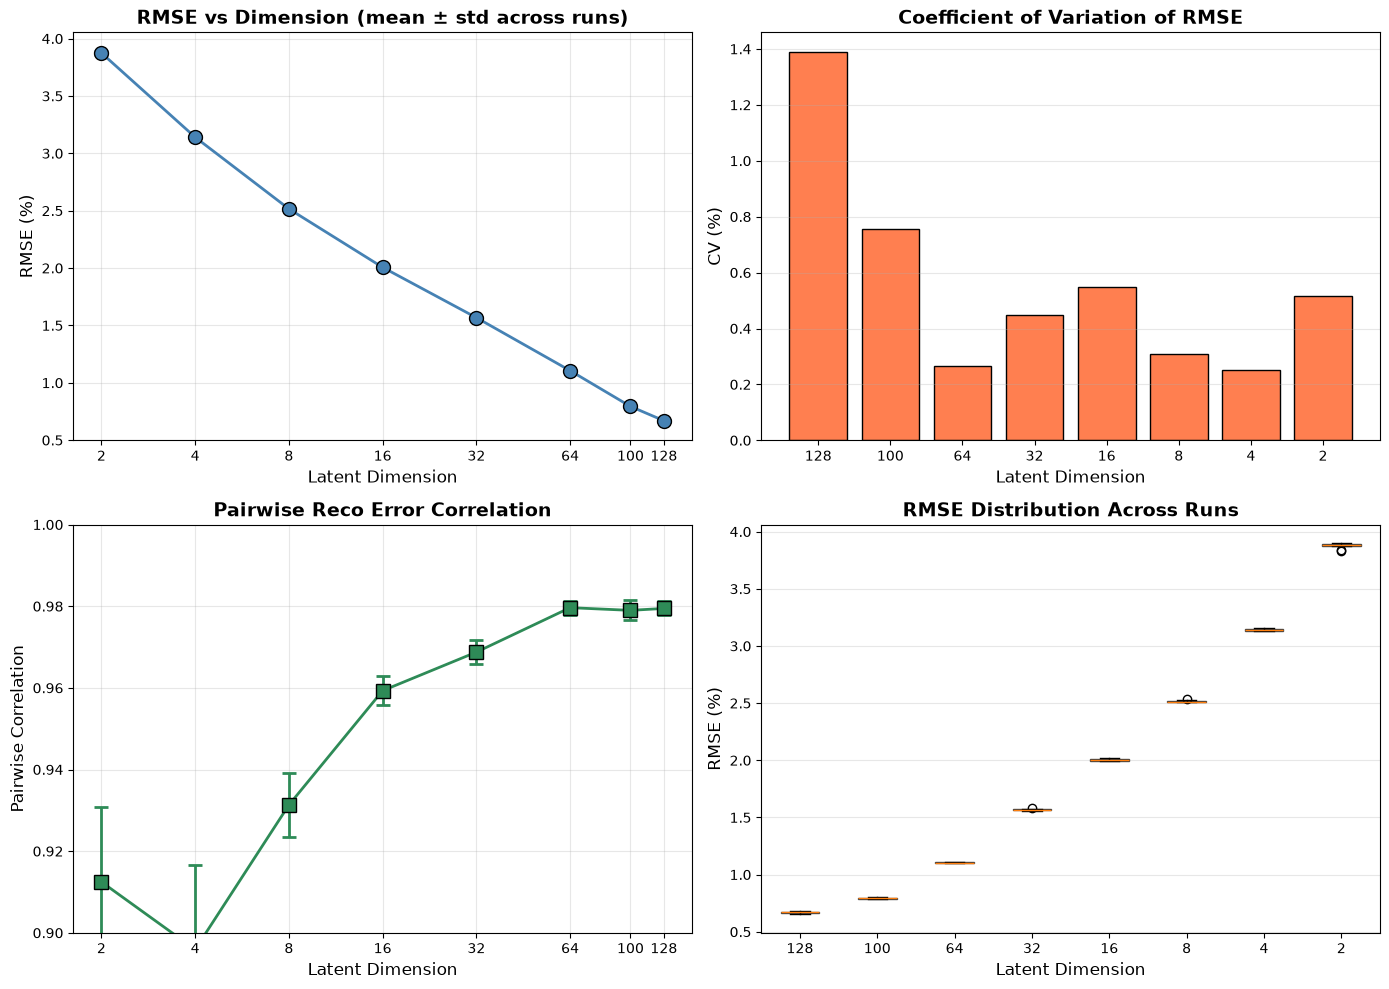

Reconstruction error stability plots saved


In [9]:
# Visualize reconstruction error stability across all bottleneck sizes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RMSE mean ± std across dimensions
rmse_means = [stability_results[dim]['rmse_mean'] * 100 for dim in bottleneck_sizes]
rmse_stds = [stability_results[dim]['rmse_std'] * 100 for dim in bottleneck_sizes]
axes[0, 0].errorbar(bottleneck_sizes, rmse_means, yerr=rmse_stds, 
                     fmt='o-', markersize=10, linewidth=2, capsize=5, capthick=2,
                     color='steelblue', markeredgecolor='black')
axes[0, 0].set_xlabel('Latent Dimension', fontsize=12)
axes[0, 0].set_ylabel('RMSE (%)', fontsize=12)
axes[0, 0].set_title('RMSE vs Dimension (mean ± std across runs)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log', base=2)
axes[0, 0].set_xticks(bottleneck_sizes)
axes[0, 0].set_xticklabels(bottleneck_sizes)

# 2. Coefficient of Variation across dimensions
cvs = [stability_results[dim]['rmse_std'] / stability_results[dim]['rmse_mean'] * 100 for dim in bottleneck_sizes]
axes[0, 1].bar(range(len(bottleneck_sizes)), cvs, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(bottleneck_sizes)))
axes[0, 1].set_xticklabels(bottleneck_sizes)
axes[0, 1].set_xlabel('Latent Dimension', fontsize=12)
axes[0, 1].set_ylabel('CV (%)', fontsize=12)
axes[0, 1].set_title('Coefficient of Variation of RMSE', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Pairwise correlation across dimensions
pairwise_corrs = [stability_results[dim]['pairwise_corr_mean'] for dim in bottleneck_sizes]
pairwise_corr_stds = [stability_results[dim]['pairwise_corr_std'] for dim in bottleneck_sizes]
axes[1, 0].errorbar(bottleneck_sizes, pairwise_corrs, yerr=pairwise_corr_stds,
                     fmt='s-', markersize=10, linewidth=2, capsize=5, capthick=2,
                     color='seagreen', markeredgecolor='black')
axes[1, 0].set_xlabel('Latent Dimension', fontsize=12)
axes[1, 0].set_ylabel('Pairwise Correlation', fontsize=12)
axes[1, 0].set_title('Pairwise Reco Error Correlation', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log', base=2)
axes[1, 0].set_xticks(bottleneck_sizes)
axes[1, 0].set_xticklabels(bottleneck_sizes)
axes[1, 0].set_ylim([0.9, 1.0])

# 4. Box plot of RMSE per run for each dimension
rmse_data = [[r * 100 for r in stability_results[dim]['rmse_per_run']] for dim in bottleneck_sizes]
bp = axes[1, 1].boxplot(rmse_data, tick_labels=bottleneck_sizes, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[1, 1].set_xlabel('Latent Dimension', fontsize=12)
axes[1, 1].set_ylabel('RMSE (%)', fontsize=12)
axes[1, 1].set_title('RMSE Distribution Across Runs', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}/reco_error_stability_all_sizes.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Reconstruction error stability plots saved")